# What is about ?

LLE - sklearn.manifold.LocallyLinearEmbedding - one out of many dimensional reduction algorithms used to visualize data ( tsne, umap - other popular tools).

**Finding Briefly.** For MoA dataset LLE produce some visually clearly seen clusters - three "strips" of lines - which clearly correlate with targets and other features.

**Challenge.** At the moment it looks mysterious - can you somehow explain it and possibly extract some benefits for prediction and more generally for  biological research.


**Context** Doing dimensional reduction is stadard for such tasks, in particular some bioinformatitions sometimes prefer LLE because it sometimes produces something like "trajectories" (or line-segments). Sometimes they are meaningless - because LLE tends to produce strainght-line looking segments even when there is not such pattern in data, but not in that case. 


-1) Pay attention - LLE has been performed on data WITHOUT CP_TIME, CP_DOSE, CP_CTL - only genes and viabilities

0) Before reading look at picture below - you will see three "strips"

1) The righest strip contains only elements with cp_time = 24 (pay attention: despite cp_time was deleted) 

2) TWO right strips have all targets = 0 for almost all points (!) (targets were NOT in data) 

3) The control group - placed in the left "strip" almost perfectly  (pay attention: despite control group flag was deleted from the data)

It seem more things can be found. Please try.


PS

I have tried to use these LLE as features for my LogReg models - but they did not improve my scores.

Other dimensional reduction plots can be found at my notebook:
https://www.kaggle.com/alexandervc/moa-data-visualization-via-dimensional-reduct
(LLE plot is also there, but now I decided to attract some attention to it, since it might be valueable not only for competition itself, but for further biological analysis). 

PSPS

Nice patterns are somewhat fragile - using slighly other settings for preprocessing - they might disapper.
Preprocessing setting was found ad hoc. 


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lish-moa/train_targets_scored.csv
/kaggle/input/lish-moa/train_drug.csv
/kaggle/input/lish-moa/train_targets_nonscored.csv
/kaggle/input/lish-moa/train_features.csv
/kaggle/input/lish-moa/sample_submission.csv
/kaggle/input/lish-moa/test_features.csv


# Load data

In [2]:
import time 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/lish-moa/train_features.csv',index_col = 0)  
df

,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,trt_cp,24,D1,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,-1.0220,...,0.2862,0.2584,0.8076,0.5523,-0.1912,0.6584,-0.3981,0.2139,0.3801,0.4176
id_000779bfc,trt_cp,72,D1,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,0.2341,...,-0.4265,0.7543,0.4708,0.0230,0.2957,0.4899,0.1522,0.1241,0.6077,0.7371
id_000a6266a,trt_cp,48,D1,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,0.1715,...,-0.7250,-0.6297,0.6103,0.0223,-1.3240,-0.3174,-0.6417,-0.2187,-1.4080,0.6931
id_0015fd391,trt_cp,48,D1,-0.5138,-0.2491,-0.2656,0.5288,4.0620,-0.8095,-1.9590,...,-2.0990,-0.6441,-5.6300,-1.3780,-0.8632,-1.2880,-1.6210,-0.8784,-0.3876,-0.8154
id_001626bd3,trt_cp,72,D2,-0.3254,-0.4009,0.9700,0.6919,1.4180,-0.8244,-0.2800,...,0.0042,0.0048,0.6670,1.0690,0.5523,-0.3031,0.1094,0.2885,-0.3786,0.7125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_fffb1ceed,trt_cp,24,D2,0.1394,-0.0636,-0.1112,-0.5080,-0.4713,0.7201,0.5773,...,0.1969,0.0262,-0.8121,0.3434,0.5372,-0.3246,0.0631,0.9171,0.5258,0.4680
id_fffb70c0c,trt_cp,24,D2,-1.3260,0.3478,-0.3743,0.9905,-0.7178,0.6621,-0.2252,...,0.4286,0.4426,0.0423,-0.3195,-0.8086,-0.9798,-0.2084,-0.1224,-0.2715,0.3689
id_fffc1c3f4,ctl_vehicle,48,D2,0.3942,0.3756,0.3109,-0.7389,0.5505,-0.0159,-0.2541,...,0.5409,0.3755,0.7343,0.2807,0.4116,0.6422,0.2256,0.7592,0.6656,0.3808


In [4]:
y = pd.read_csv('/kaggle/input/lish-moa/train_targets_nonscored.csv',index_col = 0 )
y

,abc_transporter_expression_enhancer,abl_inhibitor,ace_inhibitor,acetylcholine_release_enhancer,adenosine_deaminase_inhibitor,adenosine_kinase_inhibitor,adenylyl_cyclase_inhibitor,age_inhibitor,alcohol_dehydrogenase_inhibitor,aldehyde_dehydrogenase_activator,...,ve-cadherin_antagonist,vesicular_monoamine_transporter_inhibitor,vitamin_k_antagonist,voltage-gated_calcium_channel_ligand,voltage-gated_potassium_channel_activator,voltage-gated_sodium_channel_blocker,wdr5_mll_interaction_inhibitor,wnt_agonist,xanthine_oxidase_inhibitor,xiap_inhibitor
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000779bfc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000a6266a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_0015fd391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_001626bd3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_fffb1ceed,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffb70c0c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffc1c3f4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
mode_which_part_to_process = 'full'
if mode_which_part_to_process == 'full':
    # consider only gene expression part 
    X = df[[c for c in df.columns if ('c-' in c) or ('g-' in c)]].values
if mode_which_part_to_process == 'genes':
    # consider only gene expression part 
    X = df[[c for c in df.columns if 'g-' in c]].values
if mode_which_part_to_process == 'c':
    # consider only gene expression part 
    X = df[[c for c in df.columns if 'c-' in c]].values

X_original_save = X.copy()
print(X.shape)

y_sum = y.sum(axis = 1)
df['y_sum']=y_sum
print(y_sum.shape)
y_sum.value_counts()



(23814, 872)
(23814,)


0    19224
1     4282
2      247
3       36
4       13
7        6
5        6
dtype: int64

In [43]:
X.shape, df.shape, df.columns[-1]

((23814, 872), (23814, 876), 'y_sum')

# LLE train LLE with ad hoc found params

1) only first 5000 elements of train taken  (just taken  because otherwise it might run too long)

2) first do pca to 50 dims (standard trick in similar tasks, otherwise it might run too long)

3) random_state = 1 (for  other it also works, but not for all)

LLE: 24 sec


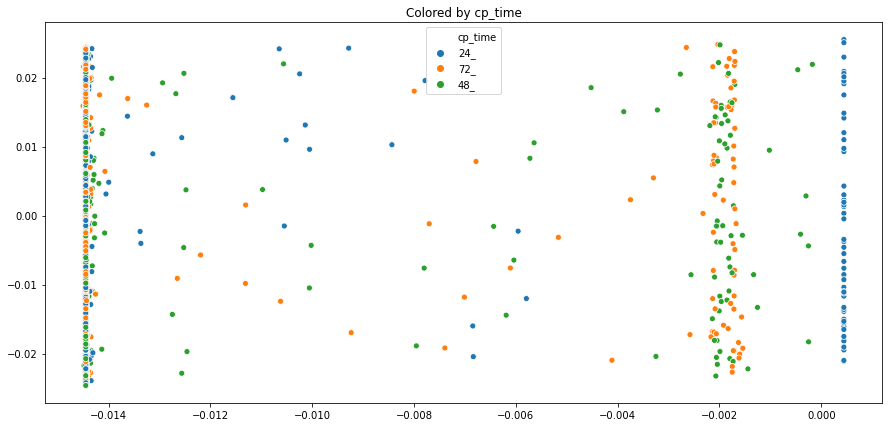

In [35]:
from sklearn import manifold
import time 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition  import PCA

pca = PCA()
# Preliminary reduce X to speed up:
r = pca.fit_transform(X.copy())
i_cut = 5000
r = r[:i_cut,:50]


n_neighbors = 10
n_components = 2
method = manifold.LocallyLinearEmbedding(n_neighbors=n_neighbors, n_components = n_components, 
                                         eigen_solver='auto', method='standard', random_state=1)# , n_jobs=-1)

t0 = time.time()
r = method.fit_transform(r)
t1 = time.time()
print("%s: %.2g sec" % ('LLE', t1 - t0))

fig = plt.figure(figsize = (15,7) )
f = 'cp_time'
c_tmp = df[f].copy().apply(lambda x: str(x)+'_' )# convert to string to avoid sns.scatterplot to interpolate numeric values in legend
sns.scatterplot(x=r[:,0], y=r[:,1] , hue =c_tmp[:i_cut]) #  df[f][:i_cut].apply(lambda x: str(x) )  )
#plt.scatter(r[:,0], y=r[:,1] , c=df[f][:i_cut]  )
#plt.legend()
plt.title('Colored by '+f)
plt.show()


# Apply trained transforms to full dataset - again see - rightest "strip" is mostly by cp_time =24 (despite cp_time was deleted from X)


LLE: 20 sec


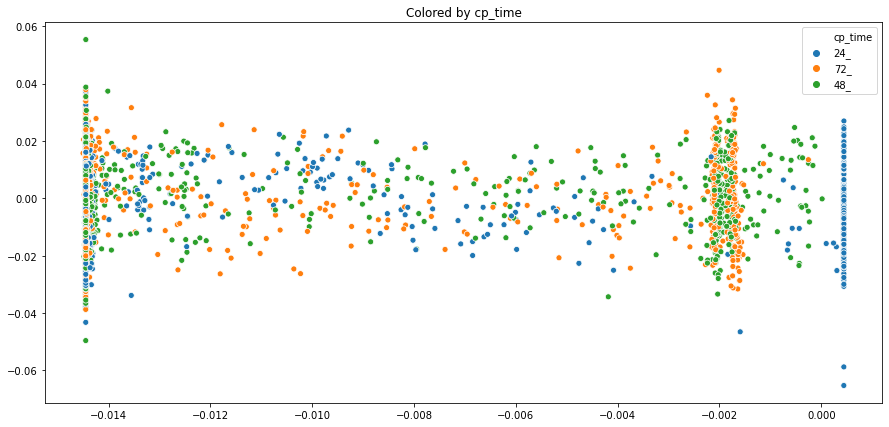

In [38]:
# Preliminary reduce X to speed up:
r = pca.transform(X.copy())

t0 = time.time()
r = method.transform(r[:,:50])
t1 = time.time()
print("%s: %.2g sec" % ('LLE', t1 - t0))

fig = plt.figure(figsize = (15,7) )
f = 'cp_time'
c_tmp = df[f].copy().apply(lambda x: str(x)+'_' )# convert to string to avoid sns.scatterplot to interpolate numeric values in legend
sns.scatterplot(x=r[:,0], y=r[:,1] , hue =c_tmp) #  df[f][:i_cut].apply(lambda x: str(x) )  )
#plt.scatter(r[:,0], y=r[:,1] , c=df[f][:i_cut]  )
#plt.legend()
plt.title('Colored by '+f)
plt.show()


# Color by target sum and other - observe on control group and targets patterns - see details below

19.122403383255005 seconds passed


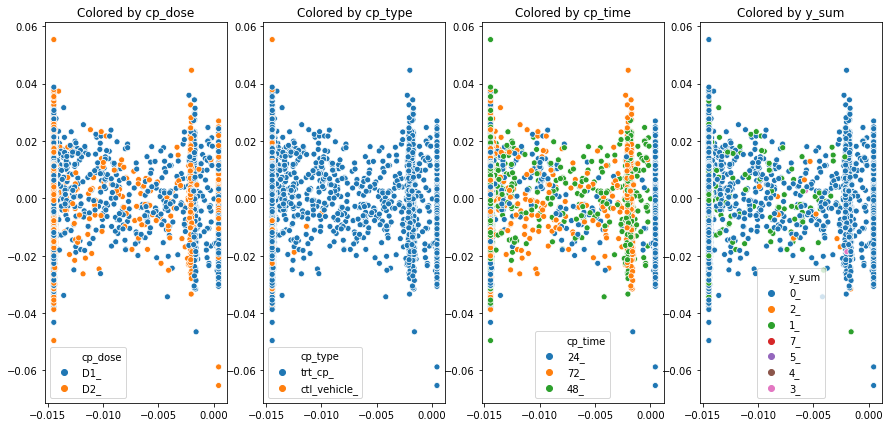

In [44]:
# Apply transform to full dataset 

r = pca.transform(X.copy() )
r = r[:,:50]

t0 = time.time()
r = method.transform(r)
print(time.time()-t0,'seconds passed')

fig = plt.figure(figsize = (15,7) )
c = 0
for f in ['cp_dose', 'cp_type','cp_time', 'y_sum']:
    c+=1; fig.add_subplot(1, 4 , c) 
    c_tmp = df[f].copy().apply(lambda x: str(x)+'_' )# convert to string to avoid sns.scatterplot to interpolate numeric values in legend
    sns.scatterplot(x=r[:,0], y=r[:,1] , hue = c_tmp  )
    plt.title('Colored by '+f)
plt.show()


# Look at control group - almost all elements - in the leftest "strip"

In [45]:
df['cp_type'].value_counts()

trt_cp         21948
ctl_vehicle     1866
Name: cp_type, dtype: int64

15.370009183883667 seconds passed


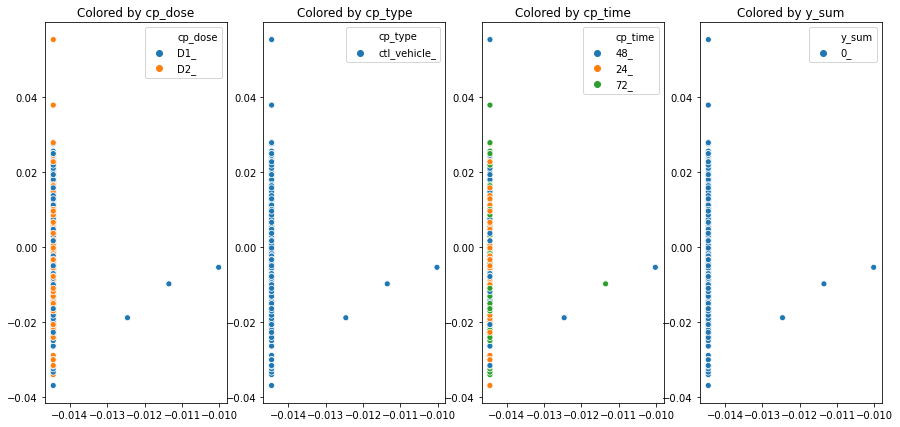

In [46]:
# Apply transform to full dataset 

r = pca.transform(X.copy() )
r = r[:,:50]

t0 = time.time()
r = method.transform(r)
print(time.time()-t0,'seconds passed')

fig = plt.figure(figsize = (15,7) )
c = 0
for f in ['cp_dose', 'cp_type','cp_time', 'y_sum']:
    c+=1; fig.add_subplot(1, 4 , c) 
    m = df['cp_type'] == 'ctl_vehicle'
    c_tmp = df[f].copy().apply(lambda x: str(x)+'_' )# convert to string to avoid sns.scatterplot to interpolate numeric values in legend
    sns.scatterplot(x=r[:,0][m], y=r[:,1][m] , hue = c_tmp[m]  )
    plt.title('Colored by '+f)
plt.show()


# Two right strips - MoA = ZERO, almost perfectly

19.577237606048584 seconds passed


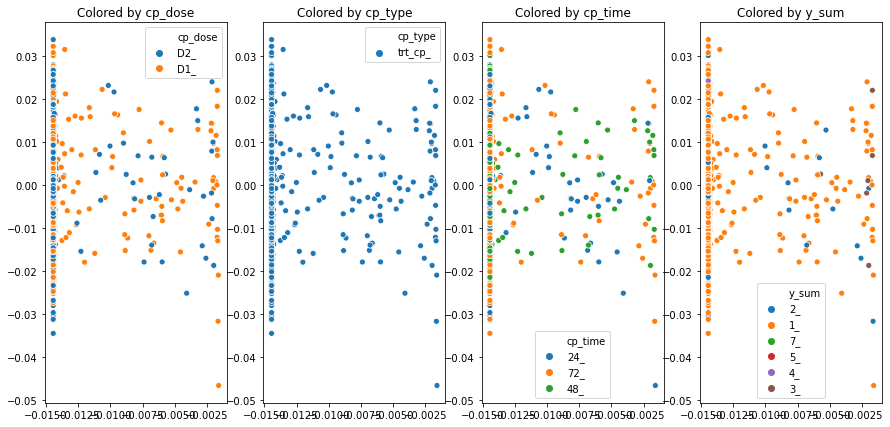

In [49]:
# Apply transform to full dataset 

r = pca.transform(X.copy() )
r = r[:,:50]

t0 = time.time()
r = method.transform(r)
print(time.time()-t0,'seconds passed')

fig = plt.figure(figsize = (15,7) )
c = 0
for f in ['cp_dose', 'cp_type','cp_time', 'y_sum']:
    c+=1; fig.add_subplot(1, 4 , c) 
    m = df['y_sum'] > 0 # dfy_sum'] == 0 # cp_type'] == 'trt_cp' #'ctl_vehicle'
    c_tmp = df[f].copy().apply(lambda x: str(x)+'_' )# convert to string to avoid sns.scatterplot to interpolate numeric values in legend
    sns.scatterplot(x=r[:,0][m], y=r[:,1][m] , hue = c_tmp[m]  )
    plt.title('Colored by '+f)
plt.show()


In [50]:
# More things should be checked - please try